**1. Import Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

**2. Load Dataset**

In [2]:
df = pd.read_csv("../data/wdbc.csv", header=None)

columns = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
df.columns = columns

df.head()

,id,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**3. Data Understanding**

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          569 non-null    int64  
 1   diagnosis   569 non-null    str    
 2   feature_1   569 non-null    float64
 3   feature_2   569 non-null    float64
 4   feature_3   569 non-null    float64
 5   feature_4   569 non-null    float64
 6   feature_5   569 non-null    float64
 7   feature_6   569 non-null    float64
 8   feature_7   569 non-null    float64
 9   feature_8   569 non-null    float64
 10  feature_9   569 non-null    float64
 11  feature_10  569 non-null    float64
 12  feature_11  569 non-null    float64
 13  feature_12  569 non-null    float64
 14  feature_13  569 non-null    float64
 15  feature_14  569 non-null    float64
 16  feature_15  569 non-null    float64
 17  feature_16  569 non-null    float64
 18  feature_17  569 non-null    float64
 19  feature_18  569 non-null    float64
 20 

,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**4. Distribusi Kelas**

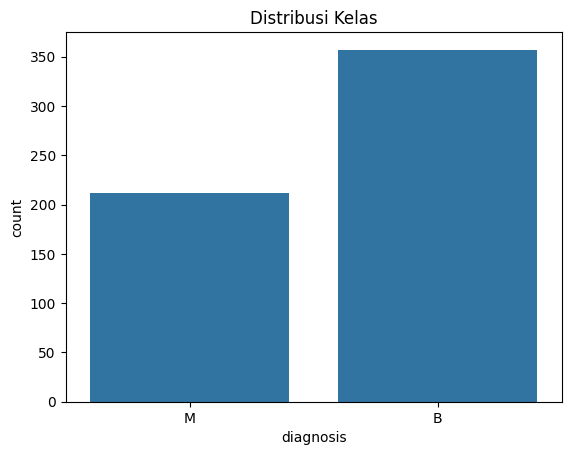

In [4]:
sns.countplot(x=df["diagnosis"])
plt.title("Distribusi Kelas")
plt.show()

**5. Preprocessing**

In [5]:
df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

**6. Split Data**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**7. Scaling**

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**8. Correlation Heatmap**

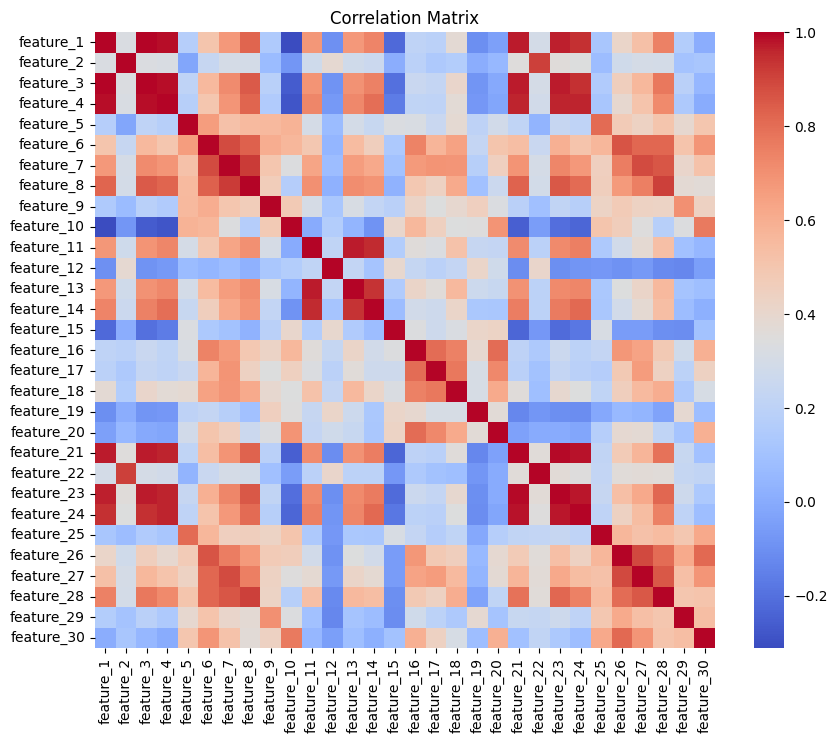

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**9.Train KNN**

In [1]:
k_values = [3,5,7,9]
best_knn = None
best_score = 0

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    
    print(f"k={k} → Accuracy={acc:.4f}")
    
    if acc > best_score:
        best_score = acc
        best_knn = model

NameError: name 'KNeighborsClassifier' is not defined

**10. Train Decision Tree**

In [10]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

**11. Train Naive Bayes**

In [11]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


**12. Function Evaluasi**

In [12]:
def evaluate(model, X_test, y_test, name):
    pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.show()
    
    return accuracy_score(y_test, pred)

**13. Evaluasi Model**


KNN
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



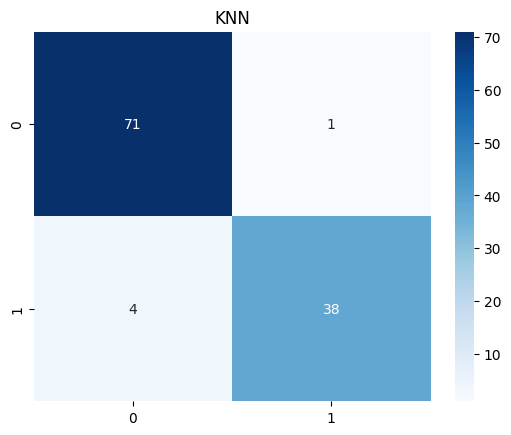


Decision Tree
Accuracy: 0.9210526315789473
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        72
           1       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



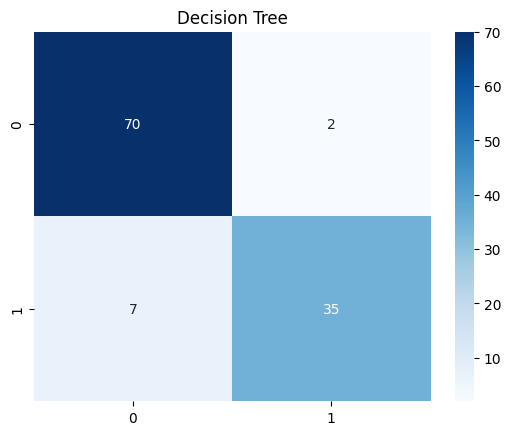


Naive Bayes
Accuracy: 0.9210526315789473
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



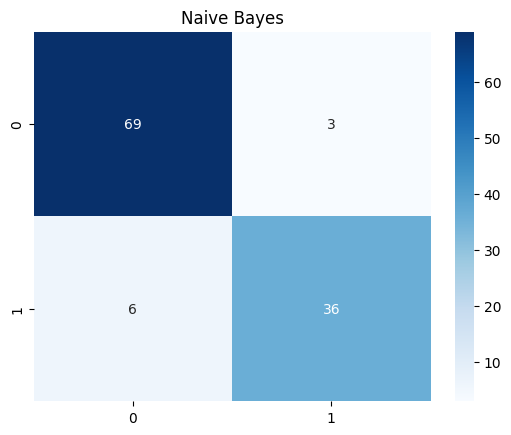

In [13]:
acc_knn = evaluate(best_knn, X_test_scaled, y_test, "KNN")
acc_dt = evaluate(dt, X_test, y_test, "Decision Tree")
acc_nb = evaluate(nb, X_test_scaled, y_test, "Naive Bayes")

**14. Perbandingan Model**

In [14]:
results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Naive Bayes"],
    "Accuracy": [acc_knn, acc_dt, acc_nb]
})

results

,Model,Accuracy
0,KNN,0.956140
1,Decision Tree,0.921053
2,Naive Bayes,0.921053


**15. Visualisasi Perbandingan**

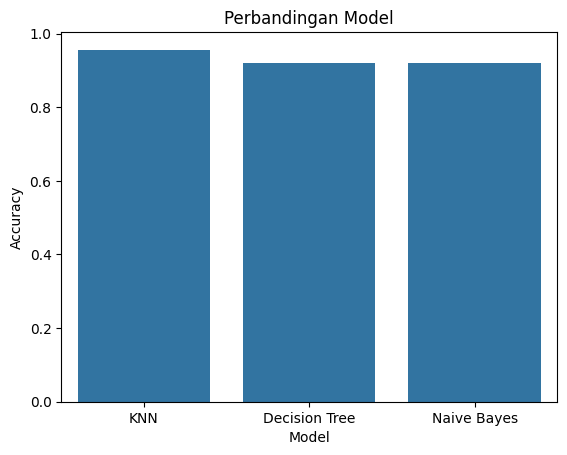

In [15]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Perbandingan Model")
plt.show()

**16. Feature Importance**

In [16]:
fs_model = DecisionTreeClassifier(random_state=42)
fs_model.fit(X_train, y_train)

importances = fs_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
22,feature_23,0.727477
27,feature_28,0.078970
24,feature_25,0.040833
1,feature_2,0.037871
21,feature_22,0.022545
3,feature_4,0.022452
20,feature_21,0.017530
23,feature_24,0.015606
7,feature_8,0.013416
16,feature_17,0.007043


**17. Visualisasi Fitur Importance**

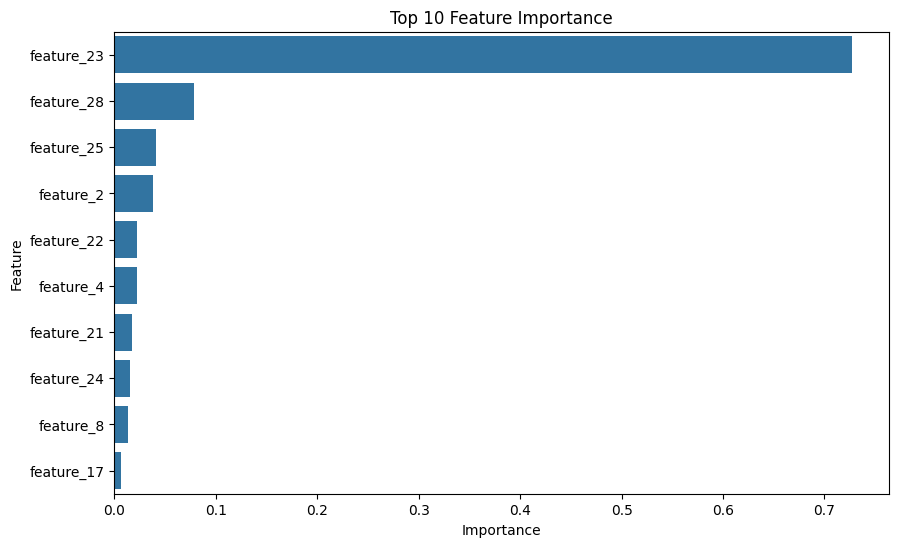

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top 10 Feature Importance")
plt.show()

**18. Demo Prediksi**

In [18]:
# ===== TEST 1: DATASET =====
sample1 = X.iloc[[0]]
sample1_scaled = scaler.transform(sample1)

pred1 = best_knn.predict(sample1_scaled)[0]
proba1 = best_knn.predict_proba(sample1_scaled)[0]

print("Test 1 (Dataset):", "Malignant" if pred1 == 1 else "Benign")
print(f"  Benign: {proba1[0]*100:.2f}%")
print(f"  Malignant: {proba1[1]*100:.2f}%")


# ===== TEST 2: MODIFIED  =====
sample2 = X.iloc[[0]] * 1.1
sample2_scaled = scaler.transform(sample2)

pred2 = best_knn.predict(sample2_scaled)[0]
proba2 = best_knn.predict_proba(sample2_scaled)[0]

print("\nTest 2 (Modified):", "Malignant" if pred2 == 1 else "Benign")
print(f"  Benign: {proba2[0]*100:.2f}%")
print(f"  Malignant: {proba2[1]*100:.2f}%")

Test 1 (Dataset): Malignant
  Benign: 0.00%
  Malignant: 100.00%

Test 2 (Modified): Malignant
  Benign: 0.00%
  Malignant: 100.00%


**19. Kesimpulan**

Model KNN memberikan performa terbaik dibandingkan Decision Tree dan Naive Bayes. Hal ini disebabkan karena dataset bersifat numerik sehingga cocok dengan pendekatan berbasis jarak. Decision Tree memiliki performa yang baik namun berpotensi overfitting, sedangkan Naive Bayes memiliki asumsi independensi fitur yang tidak sepenuhnya terpenuhi.

In [ ]:
# Input dari user
user_input = input("Masukkan 30 fitur (pisahkan dengan koma): ")

try:
    values = [float(x) for x in user_input.split(",")]
    
    if len(values) != 30:
        print("❌ Harus 30 fitur!")
    else:
        sample = pd.DataFrame([values], columns=X.columns)
        
        sample_scaled = scaler.transform(sample)
        
        pred = best_knn.predict(sample_scaled)[0]
        
        print("Hasil:", "Malignant (Ganas)" if pred == 1 else "Benign (Jinak)")

except:
    print("❌ Input tidak valid!")